# Brain Stroke Prediction

## Scenario 1: Classification
This notebook follows the project brief for the **Brain Stroke prediction** task and documents the full data science process up to model evaluation.

### Objective
Build and compare classification models that predict whether a patient is likely to have a stroke, then apply the selected model to the unseen dataset.

### Why this problem needs special care
The brief states that this is an **unbalanced dataset**, so model evaluation cannot rely on accuracy alone. In a medical-risk setting, missing a real stroke case (**false negative**) is usually more serious than incorrectly flagging a non-stroke case (**false positive**). For that reason, this notebook gives particular attention to **recall** when selecting the final model.


## Data Dictionary and Project Notes

### Datasets
- **Training dataset (`df`)**: `brain_stroke_data.csv`
- **Unseen dataset (`df_unseen`)**: `brain_stroke_unseen.csv`
- **Target variable**: `stroke`

### Analytical plan
The notebook is structured as follows:
1. Import libraries
2. Load and inspect the datasets
3. Perform exploratory data analysis (EDA)
4. Pre-process the data
5. Train and evaluate multiple classification models
6. Compare model performance
7. Select the most suitable model
8. Predict outcomes for the unseen dataset

### Model selection principle
Because this is a healthcare classification task with class imbalance, the most important goal is to identify as many true stroke cases as possible. Therefore:
- **Recall** is prioritised when selecting the final model
- **F1-score** is still considered because it balances recall and precision
- **Accuracy** is reported, but not used as the main decision metric because it can look strong even when minority stroke cases are missed


**Import Libraries**

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

**Load Datasets**

In [38]:
# Load the training dataset
df = pd.read_csv("./processed_datasets/brain_stroke/brain_stroke_data.csv")

df.head(5)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


In [39]:
# Load the unseen dataset
df_unseen = pd.read_csv("./processed_datasets/brain_stroke/brain_stroke_unseen.csv")

df_unseen.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Female,49.0,0,0,Yes,Private,Rural,56.11,28.7,smokes
1,Male,75.0,0,0,Yes,Private,Rural,75.47,24.5,formerly smoked
2,Female,71.0,0,0,Yes,Private,Rural,100.61,19.2,Unknown
3,Female,12.0,0,0,No,children,Rural,85.97,35.7,Unknown
4,Male,63.0,0,0,Yes,Private,Rural,104.79,24.1,Unknown


In [40]:
# Standardise column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(" ", "_")
df_unseen.columns = df_unseen.columns.str.lower().str.replace(" ", "_")

df.columns, df_unseen.columns   

(Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
        'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
        'smoking_status', 'stroke'],
       dtype='object'),
 Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
        'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
        'smoking_status'],
       dtype='object'))

## Exploratory Data Analysis (EDA)

EDA is used to understand:
- the structure of the dataset
- feature types
- missing values
- class imbalance in the target
- distributions of numerical variables
- relationships between features and stroke outcome

This section is important for the mark scheme because it shows both data understanding and justification for later modelling decisions.


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4482 entries, 0 to 4481
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4482 non-null   object 
 1   age                4482 non-null   float64
 2   hypertension       4482 non-null   int64  
 3   heart_disease      4482 non-null   int64  
 4   ever_married       4482 non-null   object 
 5   work_type          4482 non-null   object 
 6   residence_type     4482 non-null   object 
 7   avg_glucose_level  4482 non-null   float64
 8   bmi                4482 non-null   float64
 9   smoking_status     4482 non-null   object 
 10  stroke             4482 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 385.3+ KB
None

DataFrame Shape:
(4482, 11)
DataFrame Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'avg_glucose_level', 'bmi', 'smoking_s

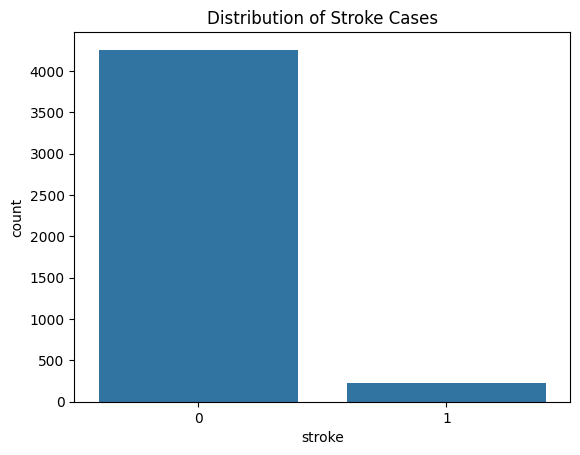

In [41]:
# Display basic information about the DataFrame
def data_info(df):
    """
    This function takes a DataFrame as input and prints basic information about it, including info, shape, columns, and missing values.
    """
    print("DataFrame Info:") # info
    print(df.info())
    print("\nDataFrame Shape:") # shape
    print(df.shape)
    print("DataFrame Columns:") # columns
    print(df.columns.tolist())  
    print("DataFrame Missing Values:") # missing values
    print(df.isna().sum())
    sns.countplot (x = "stroke", data = df) # distribution of stroke cases
    plt.title("Distribution of Stroke Cases")
    plt.show()

data_info(df)

**Initial data quality note**

No missing values were identified in the dataset at this stage, which means no imputation step is required for the current version of the data. Even so, this check is still documented because it is an essential part of the preprocessing workflow.


In [42]:
def seperate_num_cat(df):
    """
    This function takes a DataFrame as input and separates the numerical and categorical columns.
    """
    num_cols = df.select_dtypes(include=["float64"]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object", "int64"]).columns.tolist()
    cat_cols.remove("stroke") # Exclude target variable from categorical columns
    return num_cols, cat_cols

num_cols, cat_cols = seperate_num_cat(df)

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols) 

Numerical Columns: ['age', 'avg_glucose_level', 'bmi']
Categorical Columns: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status']


Numerical Data EDA


Column: age
count    4482.00
mean       43.45
std        22.59
min         0.08
25%        26.00
50%        45.00
75%        61.00
max        82.00
Name: age, dtype: float64


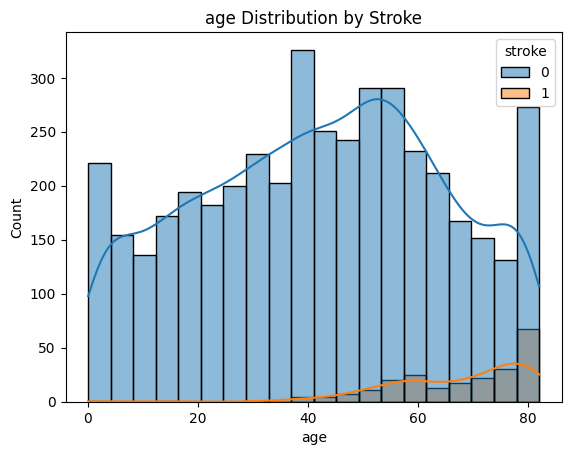

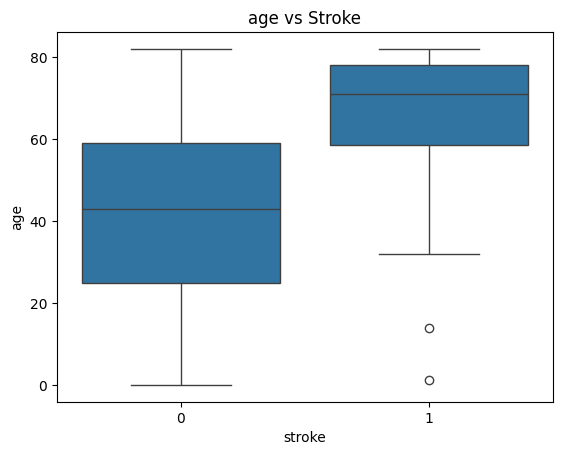


Column: avg_glucose_level
count    4482.00
mean      105.76
std        44.94
min        55.12
25%        77.19
50%        91.68
75%       113.64
max       267.76
Name: avg_glucose_level, dtype: float64


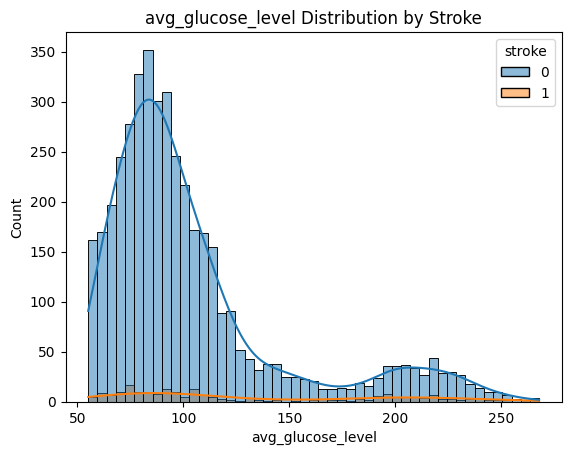

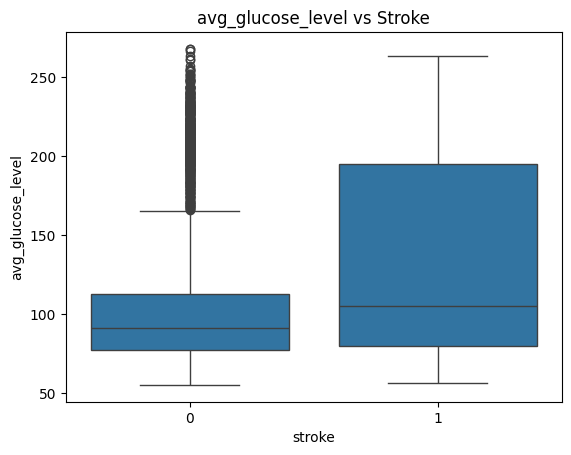


Column: bmi
count    4482.00
mean       28.47
std         6.76
min        14.00
25%        23.60
50%        28.10
75%        32.58
max        48.90
Name: bmi, dtype: float64


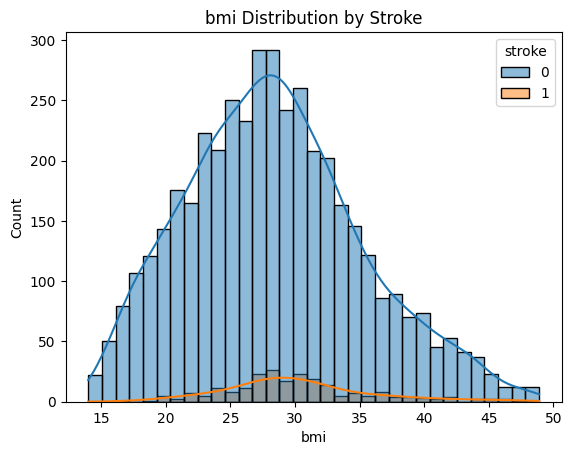

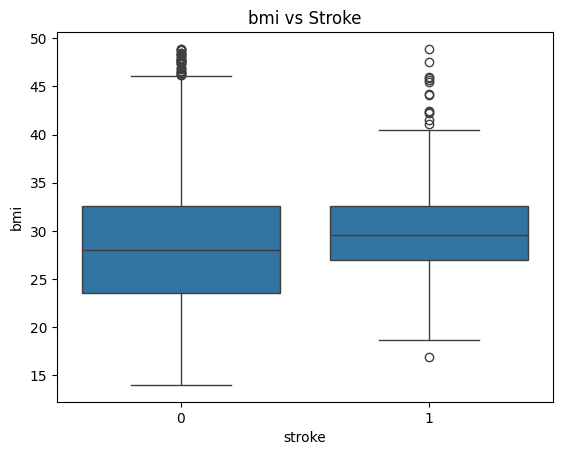

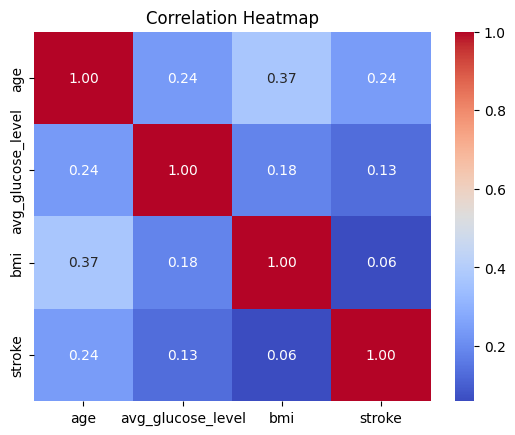

In [43]:
def numerical_eda(df, num_cols):
    """
    Performs EDA on numerical columns with comparison against target (stroke)
    """
    for col in num_cols:
        print(f"\nColumn: {col}")
        print(df[col].describe().round(2))  # Summary statistics

        # Distribution by stroke
        sns.histplot(data=df, x=col, hue="stroke", kde=True)
        plt.title(f"{col} Distribution by Stroke")
        plt.show()

        # Boxplot vs stroke
        sns.boxplot(data=df, x="stroke", y=col)
        plt.title(f"{col} vs Stroke")
        plt.show()

    # Correlation heatmap
    corr = df[num_cols + ["stroke"]].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

numerical_eda(df, num_cols)

Categorical Data EDA

gender
Female    2600
Male      1882
Name: count, dtype: int64
gender
Female    58.01
Male      41.99
Name: proportion, dtype: float64


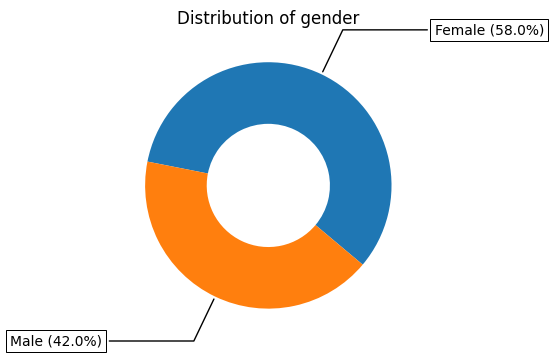

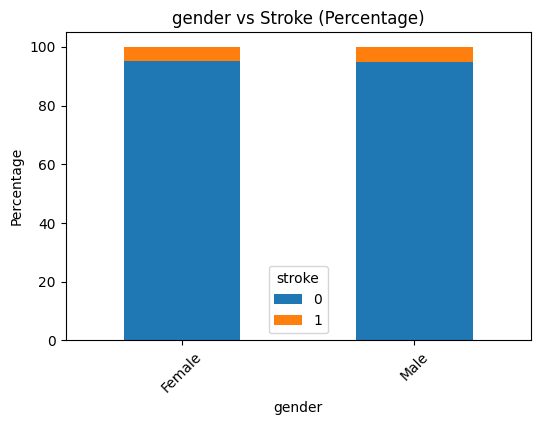

hypertension
0    4041
1     441
Name: count, dtype: int64
hypertension
0    90.16
1     9.84
Name: proportion, dtype: float64


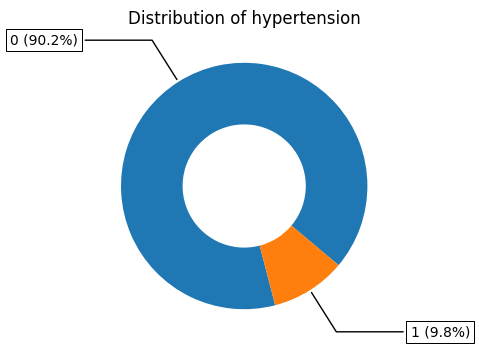

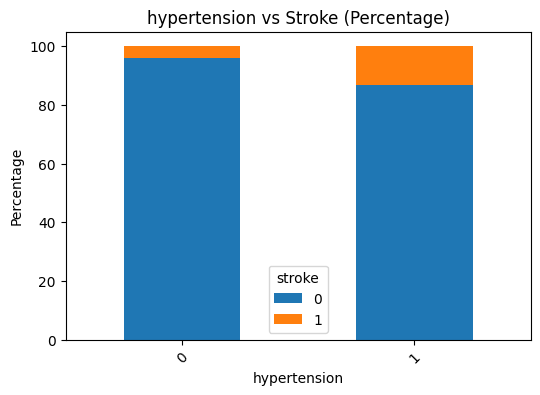

heart_disease
0    4237
1     245
Name: count, dtype: int64
heart_disease
0    94.53
1     5.47
Name: proportion, dtype: float64


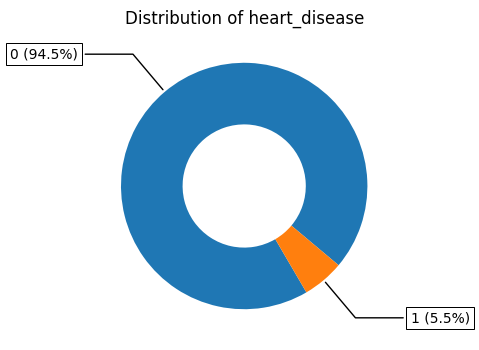

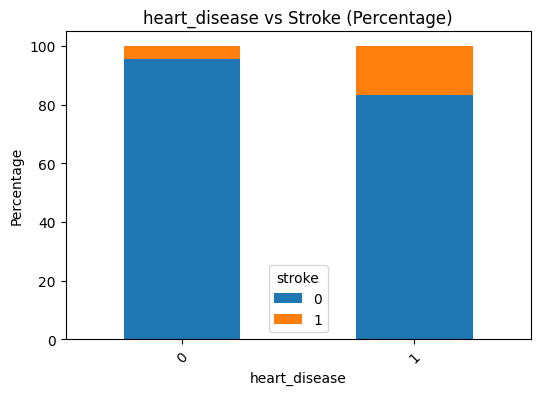

ever_married
Yes    2951
No     1531
Name: count, dtype: int64
ever_married
Yes    65.84
No     34.16
Name: proportion, dtype: float64


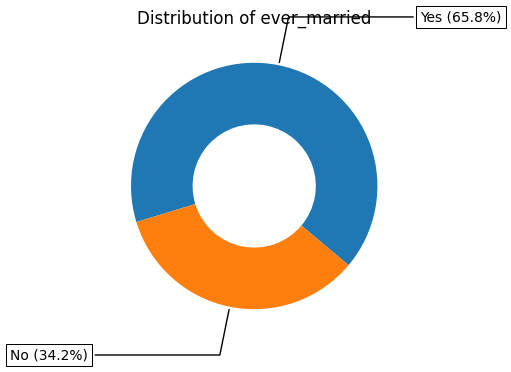

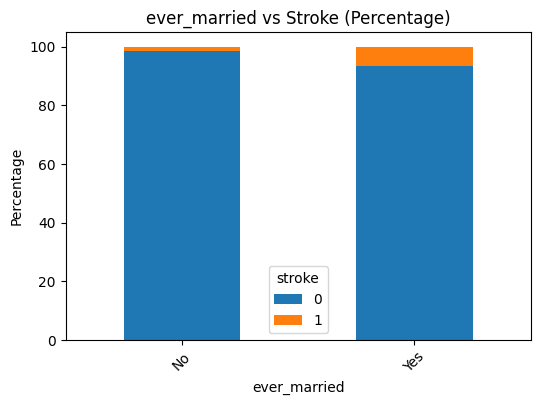

work_type
Private          2571
Self-employed     721
children          602
Govt_job          588
Name: count, dtype: int64
work_type
Private          57.36
Self-employed    16.09
children         13.43
Govt_job         13.12
Name: proportion, dtype: float64


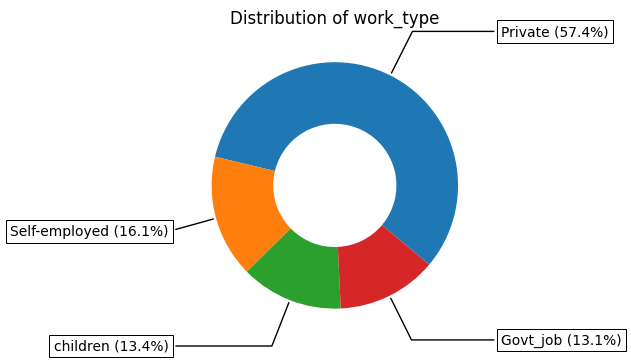

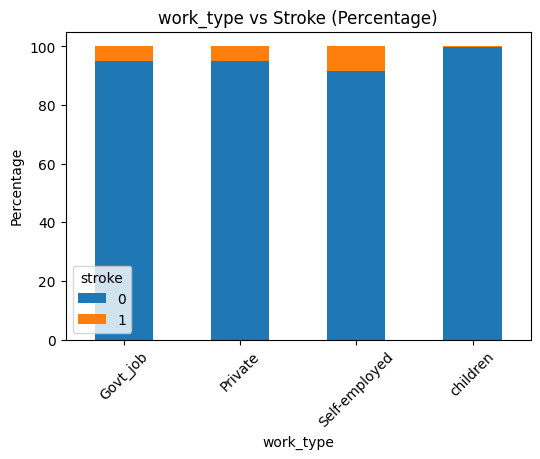

residence_type
Urban    2282
Rural    2200
Name: count, dtype: int64
residence_type
Urban    50.91
Rural    49.09
Name: proportion, dtype: float64


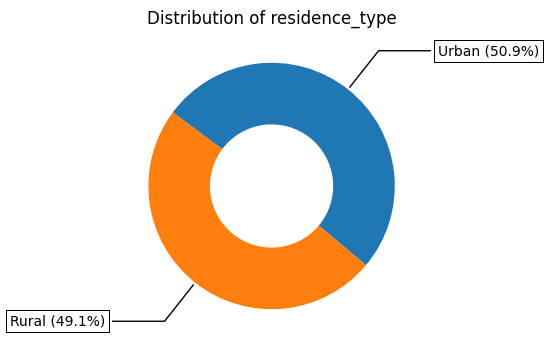

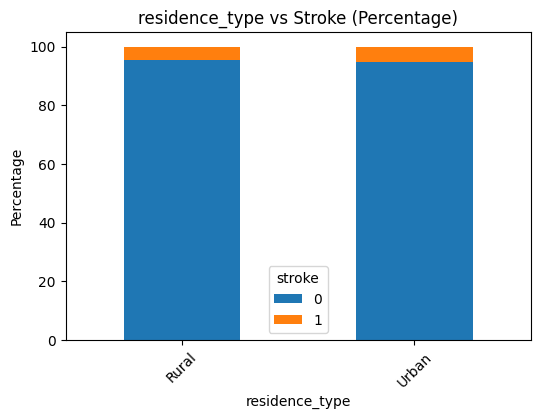

smoking_status
never smoked       1665
Unknown            1352
formerly smoked     759
smokes              706
Name: count, dtype: int64
smoking_status
never smoked       37.15
Unknown            30.17
formerly smoked    16.93
smokes             15.75
Name: proportion, dtype: float64


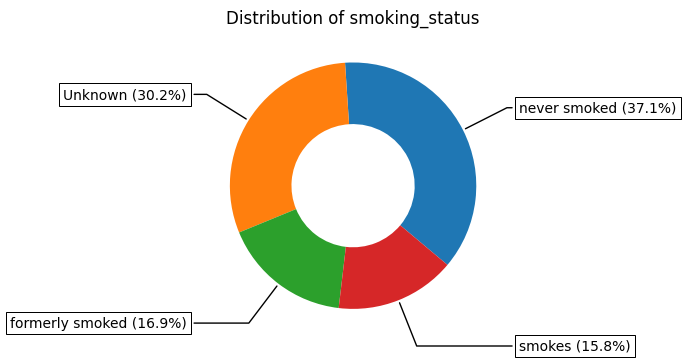

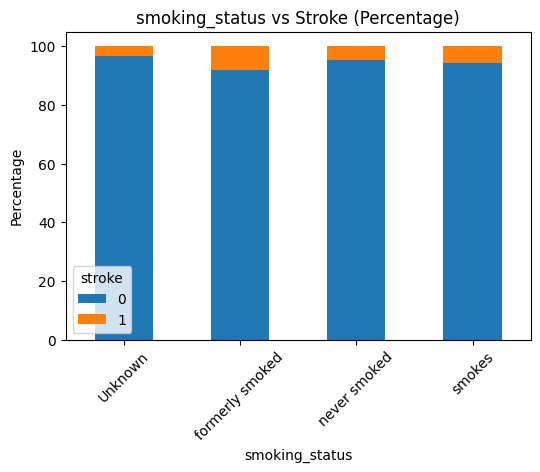

In [44]:
def categorical_eda(df, cat_cols):
    """
    Performs categorical EDA with:
    1. Distribution summary
    2. Donut chart
    3. Stacked bar chart of category proportions vs stroke
    """
    
    for col in cat_cols:
        print(df[col].value_counts(dropna=False))
        print(round(df[col].value_counts(normalize=True, dropna=False) * 100, 2))

        # Donut chart
        # Pie chart code reference from: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html
        counts = df[col].value_counts(dropna=False)
        labels = counts.index.astype(str)
        data = counts.values
        total = data.sum()

        fig, ax = plt.subplots(figsize=(6, 4), subplot_kw=dict(aspect="equal"))

        wedges, texts = ax.pie(
            data,
            wedgeprops=dict(width=0.5),
            startangle=-40
        )

        bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
        kw = dict(
            arrowprops=dict(arrowstyle="-"),
            bbox=bbox_props,
            zorder=0,
            va="center"
        )

        for i, p in enumerate(wedges):
            ang = (p.theta2 - p.theta1) / 2. + p.theta1
            y = np.sin(np.deg2rad(ang))
            x = np.cos(np.deg2rad(ang))

            horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
            connectionstyle = f"angle,angleA=0,angleB={ang}"
            kw["arrowprops"].update({"connectionstyle": connectionstyle})

            percentage = data[i] / total * 100

            ax.annotate(
                f"{labels[i]} ({percentage:.1f}%)",
                xy=(x, y),
                xytext=(1.35 * np.sign(x), 1.4 * y),
                horizontalalignment=horizontalalignment,
                **kw
            )

        ax.set_title(f"Distribution of {col}")
        plt.show()

        # Stacked percentage bar chart vs stroke 
        ct = pd.crosstab(df[col], df["stroke"], normalize="index") * 100
        ct.plot(kind="bar", stacked=True, figsize=(6, 4))
        plt.title(f"{col} vs Stroke (Percentage)")
        plt.ylabel("Percentage")
        plt.xticks(rotation=45)
        plt.legend(title="stroke")
        plt.show()
    
categorical_eda(df, cat_cols)

## Pre-processing

The aim of preprocessing is to convert the raw dataset into a form suitable for machine learning while avoiding data leakage.

### Decisions made
- Categorical variables are one-hot encoded
- Numerical variables are standardised
- Data is split into training and testing sets **before** scaling
- SMOTE is applied **only to the training set** to address class imbalance

These decisions are documented because the brief asks for justification of assumptions, transformations, and what is left in or removed from the model.


### Encode categorical variables

Categorical variables are converted into a numerical format using **OneHotEncoder**.  
This is appropriate because most classification algorithms used later require numeric input, and one-hot encoding avoids introducing artificial ordinal relationships between categories.


In [45]:
# One-hot encode the categorical variables so that ML models can use them
# handle_unknown='ignore' allows the unseen dataset to contain categories not present in training
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

onehot_encoded = encoder.fit_transform(df[cat_cols])
one_hot_df = pd.DataFrame(
    onehot_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)

# Combine numerical features, encoded categorical features, and the target
df_encoded = pd.concat([df[num_cols], one_hot_df, df["stroke"]], axis=1)

df_encoded.head()


,age,avg_glucose_level,bmi,gender_Female,gender_Male,hypertension_0,hypertension_1,heart_disease_0,heart_disease_1,ever_married_No,...,work_type_Private,work_type_Self-employed,work_type_children,residence_type_Rural,residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,46.0,78.79,42.4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
1,65.0,248.24,27.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
2,70.0,118.81,26.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
3,47.0,111.84,33.7,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0
4,31.0,65.70,30.4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0


### Standardisation

Standardisation is applied only to the numerical columns so that models based on distance or optimisation, such as **KNN**, **SVM**, and **Logistic Regression**, are not dominated by variables with larger scales.


The dataset is split into training and testing sets **before** standard scaling to prevent **data leakage**.  
Only the training data is used to fit the scaler, and the same fitted scaler is then applied to the test data.


In [46]:
# Separate features (X) and target (y)
X = df_encoded.drop("stroke", axis=1)
y = df_encoded["stroke"]

# Split the data into train and test sets
# stratify=y preserves the class distribution across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((3585, 21), (897, 21), (3585,), (897,))

In [47]:
# Standardise only the original numerical columns
# Fit on training data only, then transform both training and test sets
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()


,age,avg_glucose_level,bmi,gender_Female,gender_Male,hypertension_0,hypertension_1,heart_disease_0,heart_disease_1,ever_married_No,...,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,residence_type_Rural,residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
3319,0.427070,-0.099995,0.588192,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1468,0.382850,-0.852297,0.396257,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
97,-0.280445,-0.643692,-1.035870,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2774,0.382850,-0.842805,0.839183,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
999,-0.413104,0.951197,1.621685,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


### Handle class imbalance with SMOTE

The project brief notes that this is an **unbalanced dataset**.  
To reduce bias towards the majority class, **SMOTE** is applied to the training set only. This creates synthetic minority-class examples and helps the models learn stroke patterns more effectively without contaminating the test set.


In [48]:
# Apply SMOTE only to the training set to avoid leaking synthetic information into the test set
sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before resampling:")
print(y_train.value_counts())
print("\nAfter resampling:")
print(y_train_res.value_counts())


Before resampling:
stroke
0    3407
1     178
Name: count, dtype: int64

After resampling:
stroke
0    3407
1    3407
Name: count, dtype: int64


## Train and Evaluate Classification Models

The notebook compares four classification models covered during the module:
- K-Nearest Neighbours (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Logistic Regression

For each model, simple parameter tuning is performed and performance is evaluated using:
- Accuracy
- Precision
- Recall
- F1-score

This supports the brief requirement to implement, compare, and justify multiple models.


### K-Nearest Neighbours (KNN)

KNN is a distance-based classifier. Different values of **k** are tested to find a suitable balance between underfitting and overfitting.

- Small `k` can be too sensitive to noise
- Large `k` can oversmooth the decision boundary

The best value is selected by comparing evaluation metrics on the test set.


In [49]:
def evaluate_knn_k_values(k_values, X_train, y_train, X_test, y_test):
    results = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)

        results.append({
            "k": k,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0)
        })

    return pd.DataFrame(results)

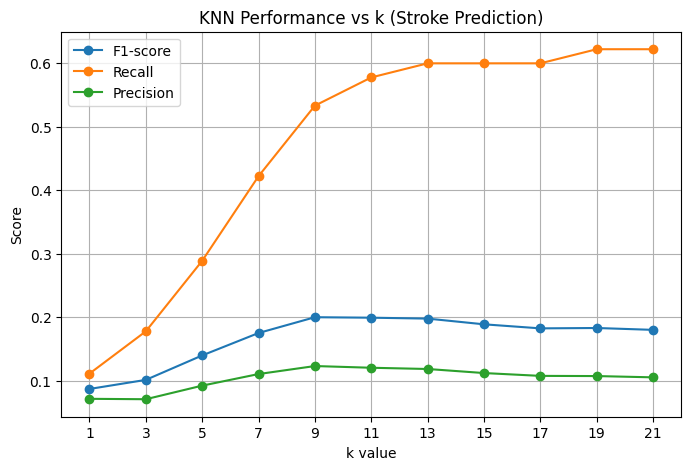

In [50]:
k_values = range(1, 22, 2)
knn_results = evaluate_knn_k_values(k_values, X_train_res, y_train_res, X_test, y_test)

plt.figure(figsize=(8,5))

plt.plot(knn_results["k"], knn_results["f1_score"], marker="o", label="F1-score")
plt.plot(knn_results["k"], knn_results["recall"], marker="o", label="Recall")
plt.plot(knn_results["k"], knn_results["precision"], marker="o", label="Precision")

plt.xlabel("k value")
plt.ylabel("Score")
plt.title("KNN Performance vs k (Stroke Prediction)")
plt.xticks(knn_results["k"])
plt.legend()
plt.grid(True)

plt.show()

In [51]:
# For KNN, recall is prioritised first because missing stroke cases is costly
# F1-score is used as a secondary check to keep some balance with precision
best_knn_row = knn_results.sort_values(
    by=["recall", "f1_score"],
    ascending=False
).iloc[0]

best_k = int(best_knn_row["k"])
print("Best k:", best_k)
print(best_knn_row)


Best k: 19
k            19.000000
accuracy      0.721293
precision     0.107280
recall        0.622222
f1_score      0.183007
Name: 9, dtype: float64


In [52]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_res, y_train_res)
y_pred_knn = final_knn.predict(X_test)

knn_final_results = {
    "model": "KNN",
    "best_param": f"k={best_k}",
    "accuracy": accuracy_score(y_test, y_pred_knn),
    "precision": precision_score(y_test, y_pred_knn, zero_division=0),
    "recall": recall_score(y_test, y_pred_knn, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_knn, zero_division=0)
}

### Support Vector Machine (SVM)

SVM is tested using both **linear** and **RBF** kernels and a range of `C` values.

- `C` controls the trade-off between allowing classification errors and enforcing a stricter margin
- Different kernels allow the model to capture either linear or more complex non-linear patterns


In [53]:
def evaluate_svm(C_values, kernels, X_train, y_train, X_test, y_test):
    results = []

    for C in C_values:
        for kernel in kernels:
            svm = SVC(C=C, kernel=kernel, random_state=42)
            svm.fit(X_train, y_train)
            y_pred = svm.predict(X_test)

            results.append({
                "C": C,
                "kernel": kernel,
                "accuracy": accuracy_score(y_test, y_pred),
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "f1_score": f1_score(y_test, y_pred, zero_division=0)
            })

    return pd.DataFrame(results)

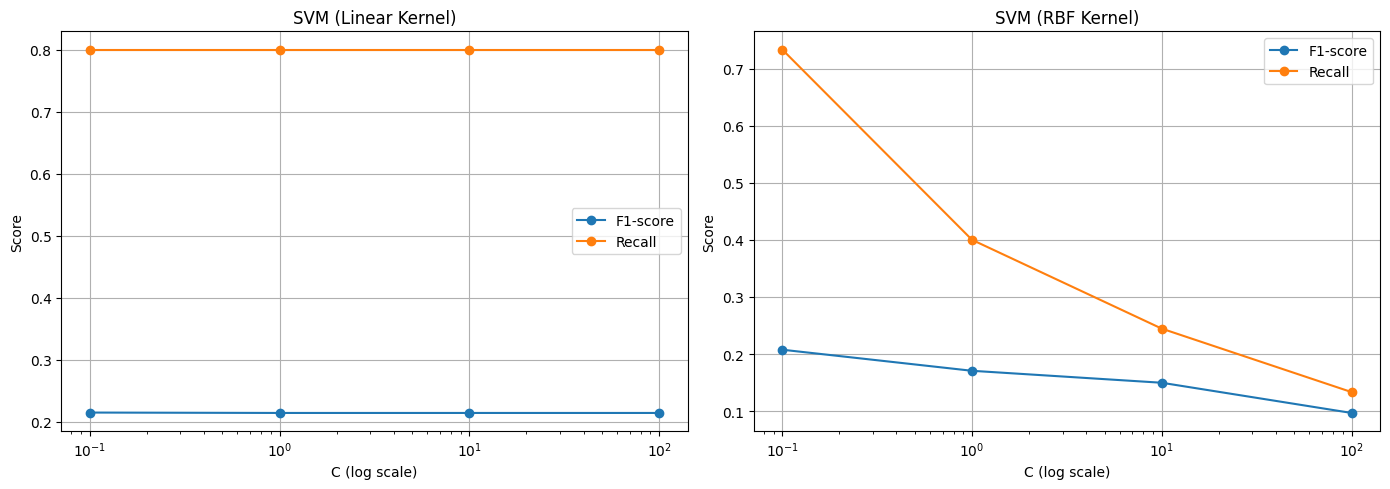

In [54]:
svm_results = evaluate_svm(
    C_values=[0.1, 1, 10, 100],
    kernels=["linear", "rbf"],
    X_train=X_train_res,
    y_train=y_train_res,
    X_test=X_test,
    y_test=y_test
)

linear_df = svm_results[svm_results["kernel"] == "linear"]
rbf_df = svm_results[svm_results["kernel"] == "rbf"]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Linear kernel
axes[0].plot(linear_df["C"], linear_df["f1_score"], marker="o", label="F1-score")
axes[0].plot(linear_df["C"], linear_df["recall"], marker="o", label="Recall")
axes[0].set_xscale("log")
axes[0].set_title("SVM (Linear Kernel)")
axes[0].set_xlabel("C (log scale)")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].grid(True)

# RBF kernel
axes[1].plot(rbf_df["C"], rbf_df["f1_score"], marker="o", label="F1-score")
axes[1].plot(rbf_df["C"], rbf_df["recall"], marker="o", label="Recall")
axes[1].set_xscale("log")
axes[1].set_title("SVM (RBF Kernel)")
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [55]:
# Select the SVM setting that performs best on recall first, then F1-score
best_svm_row = svm_results.sort_values(
    by=["recall", "f1_score"],
    ascending=False
).iloc[0]

best_C = best_svm_row["C"]
best_kernel = best_svm_row["kernel"]

print("Best SVM:")
print(best_svm_row)


Best SVM:
C                 0.1
kernel         linear
accuracy       0.7068
precision    0.124138
recall            0.8
f1_score     0.214925
Name: 0, dtype: object


In [56]:
final_svm = SVC(C=best_C, kernel=best_kernel, random_state=42)
final_svm.fit(X_train_res, y_train_res)
y_pred_svm = final_svm.predict(X_test)

svm_final_results = {
    "model": "SVM",
    "best_param": f"C={best_C}, kernel={best_kernel}",
    "accuracy": accuracy_score(y_test, y_pred_svm),
    "precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "recall": recall_score(y_test, y_pred_svm, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_svm, zero_division=0)
}

### Decision Tree

Decision Tree models are interpretable and can capture non-linear rules.  
The main parameter tuned here is `max_depth`, which controls model complexity.

- Very shallow trees may underfit
- Very deep trees may overfit

Testing multiple depths helps justify the final parameter choice.


In [57]:
def evaluate_decision_tree(depth_values, X_train, y_train, X_test, y_test):
    results = []

    for depth in depth_values:
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
        dt.fit(X_train, y_train)
        y_pred = dt.predict(X_test)

        results.append({
            "max_depth": depth,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0)
        })

    return pd.DataFrame(results)

In [58]:
depth_values = [2, 3, 4, 5, 6, 8, 10, 12, None]
dt_results = evaluate_decision_tree(depth_values, X_train_res, y_train_res, X_test, y_test)

In [59]:
# Select the Decision Tree with the strongest recall, using F1-score as a tie-breaker
best_dt_row = dt_results.sort_values(
    by=["recall", "f1_score"],
    ascending=False
).iloc[0]

best_depth = best_dt_row["max_depth"]
best_depth = None if pd.isna(best_depth) else int(best_depth)

print("Best Decision Tree depth:", best_depth)
print(best_dt_row)


Best Decision Tree depth: 2
max_depth    2.000000
accuracy     0.714604
precision    0.119134
recall       0.733333
f1_score     0.204969
Name: 0, dtype: float64


In [60]:
final_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_dt.fit(X_train_res, y_train_res)
y_pred_dt = final_dt.predict(X_test)

dt_final_results = {
    "model": "Decision Tree",
    "best_param": f"max_depth={best_depth}",
    "accuracy": accuracy_score(y_test, y_pred_dt),
    "precision": precision_score(y_test, y_pred_dt, zero_division=0),
    "recall": recall_score(y_test, y_pred_dt, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_dt, zero_division=0)
}

### Logistic Regression

Logistic Regression is included as a strong baseline classifier.  
It is simple, interpretable, and often performs well on structured tabular data.

Different values of `C` are tested:
- Smaller `C` means stronger regularisation
- Larger `C` means weaker regularisation


In [61]:
def evaluate_logistic_regression(C_values, X_train, y_train, X_test, y_test):
    results = []

    for C in C_values:
        lr = LogisticRegression(
            C=C,
            max_iter=1000,
            random_state=42
        )

        lr.fit(X_train, y_train)
        y_pred = lr.predict(X_test)

        results.append({
            "C": C,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0)
        })

    return pd.DataFrame(results)

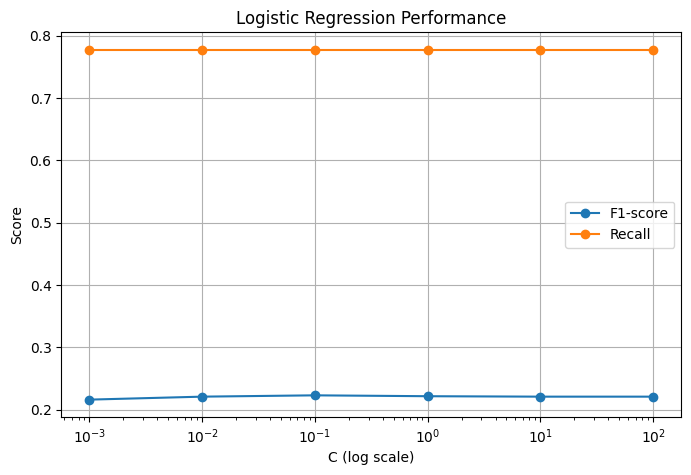

In [62]:
lr_results = evaluate_logistic_regression(
    C_values=[0.001, 0.01, 0.1, 1, 10, 100],
    X_train=X_train_res,
    y_train=y_train_res,
    X_test=X_test,
    y_test=y_test
)

plt.figure(figsize=(8,5))

plt.plot(lr_results["C"], lr_results["f1_score"], marker="o", label="F1-score")
plt.plot(lr_results["C"], lr_results["recall"], marker="o", label="Recall")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Score")
plt.title("Logistic Regression Performance")
plt.legend()
plt.grid(True)

plt.show()

In [63]:
# Select the Logistic Regression setting with highest recall, then F1-score
best_lr_row = lr_results.sort_values(
    by=["recall", "f1_score"],
    ascending=False
).iloc[0]

best_lr_C = best_lr_row["C"]

print("Best Logistic Regression C:", best_lr_C)
print(best_lr_row)


Best Logistic Regression C: 0.1
C            0.100000
accuracy     0.727982
precision    0.130112
recall       0.777778
f1_score     0.222930
Name: 2, dtype: float64


In [64]:
final_lr = LogisticRegression(
    C=best_lr_C,
    max_iter=1000,
    random_state=42
)

final_lr.fit(X_train_res, y_train_res)
y_pred_lr = final_lr.predict(X_test)

lr_final_results = {
    "model": "Logistic Regression",
    "best_param": f"C={best_lr_C}",
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "recall": recall_score(y_test, y_pred_lr, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_lr, zero_division=0)
}

## Compare Model Performance

After tuning each model, the final versions are compared in one table and one chart.

### Why recall matters most here
In stroke prediction, a **false negative** means the model predicts that a patient is low risk when they are actually a stroke case. In a healthcare context, that is usually more costly than a false positive.

Therefore:
- **Recall** is prioritised because it measures how many actual stroke cases were correctly identified
- **F1-score** is still important because it balances recall and precision
- **Accuracy** is not enough on its own because a model can appear accurate simply by predicting the majority class well

For that reason, the final model is selected primarily by **recall**, with **F1-score** used as a secondary check.


In [65]:
# Collect the final evaluation results for all tuned models
all_model_results = [
    knn_final_results,
    svm_final_results,
    dt_final_results,
    lr_final_results
]

comparison_df = pd.DataFrame(all_model_results)

# Sort by recall first because this is the primary business/clinical objective
print(comparison_df.sort_values(by=["recall", "f1_score"], ascending=False))


                 model            best_param  accuracy  precision    recall  \
1                  SVM  C=0.1, kernel=linear  0.706800   0.124138  0.800000   
3  Logistic Regression                 C=0.1  0.727982   0.130112  0.777778   
2        Decision Tree           max_depth=2  0.714604   0.119134  0.733333   
0                  KNN                  k=19  0.721293   0.107280  0.622222   

   f1_score  
1  0.214925  
3  0.222930  
2  0.204969  
0  0.183007  


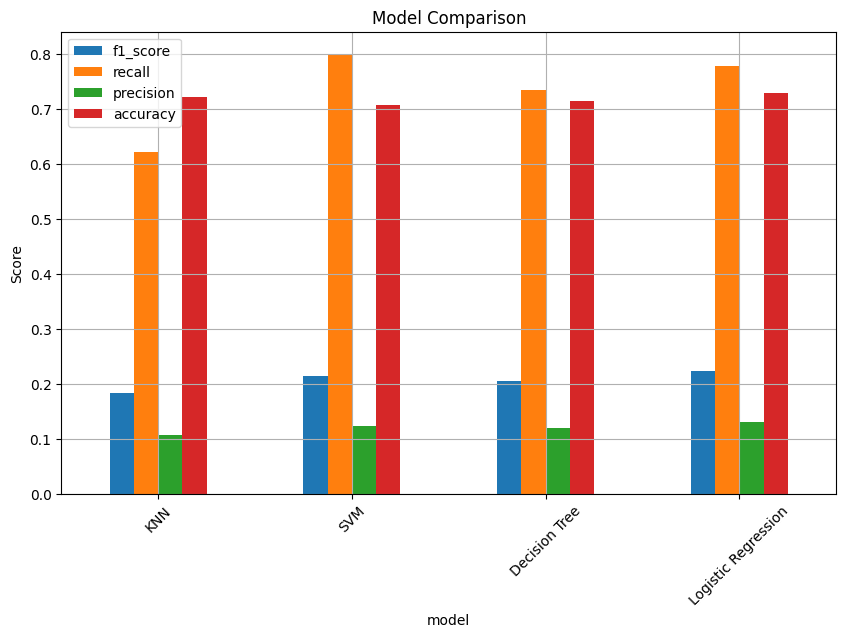

In [66]:
comparison_df.set_index("model")[["f1_score", "recall", "precision", "accuracy"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


KNN
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.83       852
           1       0.11      0.62      0.18        45

    accuracy                           0.72       897
   macro avg       0.54      0.67      0.51       897
weighted avg       0.93      0.72      0.80       897



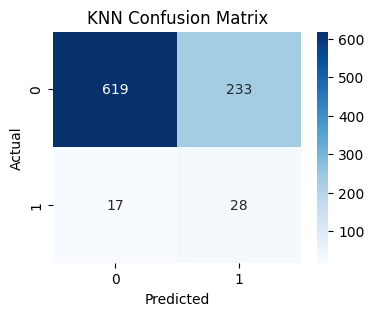


SVM
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.70      0.82       852
           1       0.12      0.80      0.21        45

    accuracy                           0.71       897
   macro avg       0.55      0.75      0.52       897
weighted avg       0.94      0.71      0.79       897



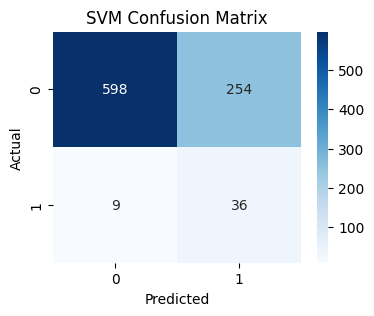


Decision Tree
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.71      0.83       852
           1       0.12      0.73      0.20        45

    accuracy                           0.71       897
   macro avg       0.55      0.72      0.52       897
weighted avg       0.94      0.71      0.79       897



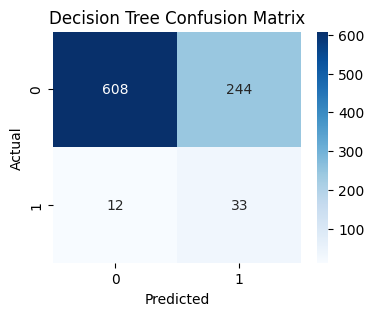


Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.84       852
           1       0.13      0.78      0.22        45

    accuracy                           0.73       897
   macro avg       0.56      0.75      0.53       897
weighted avg       0.94      0.73      0.80       897



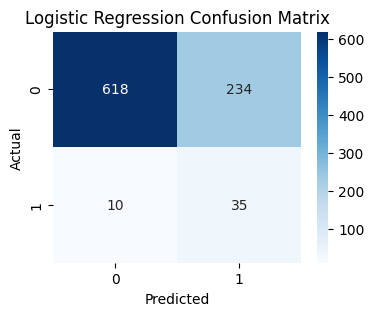

In [67]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix helps show false positives and false negatives clearly
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("SVM", y_test, y_pred_svm)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Logistic Regression", y_test, y_pred_lr)


In [68]:
# Select the final model using recall as the main decision metric
# This is justified because failing to detect a true stroke case is more serious
best_model_row = comparison_df.sort_values(
    by=["recall", "f1_score"],
    ascending=False
).iloc[0]

best_model_name = best_model_row["model"]

# Map model names to the trained model objects
model_dict = {
    "KNN": final_knn,
    "SVM": final_svm,
    "Decision Tree": final_dt,
    "Logistic Regression": final_lr
}

best_model = model_dict[best_model_name]

print("Best model selected:", best_model_name)
print(best_model_row)


Best model selected: SVM
model                          SVM
best_param    C=0.1, kernel=linear
accuracy                    0.7068
precision                 0.124138
recall                         0.8
f1_score                  0.214925
Name: 1, dtype: object


## Apply the Selected Model to the Unseen Dataset

The same fitted preprocessing steps are applied to the unseen dataset:
1. One-hot encode categorical variables using the encoder fitted on the training data
2. Align the unseen columns to match the training feature space
3. Standardise numerical columns using the fitted scaler
4. Generate final predictions with the selected model

This ensures the unseen data is treated consistently with the training pipeline.


Encode Unseen Data

In [69]:
# Transform the unseen categorical columns with the encoder fitted on training data
onehot_encoded = encoder.transform(df_unseen[cat_cols])
one_hot_df = pd.DataFrame(
    onehot_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df_unseen.index
)

# Rebuild the unseen feature set in the same column order used by the trained models
df_unseen_encoded = pd.concat([df_unseen[num_cols], one_hot_df], axis=1)
df_unseen_encoded = df_unseen_encoded.reindex(columns=X_train_res.columns, fill_value=0)

# Apply the same fitted scaler to unseen numerical columns
df_unseen_encoded[num_cols] = scaler.transform(df_unseen_encoded[num_cols])


Prediction

In [70]:
# Generate final predictions for the unseen dataset
predictions = best_model.predict(df_unseen_encoded)
df_unseen["Predictions"] = predictions

print(df_unseen["Predictions"].value_counts())


Predictions
0    332
1    167
Name: count, dtype: int64


In [71]:
best_model.predict(df_unseen_encoded)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,

In [72]:
# Save predictions to CSV for submission
df_unseen.to_csv("./processed_datasets/brain_stroke/brain_stroke_predictions.csv", index=False)


## Conclusion, Lessons Learned, and Future Work

### Conclusion
This notebook followed the project brief by completing the full classification workflow: EDA, preprocessing, model training, parameter testing, evaluation, comparison, and prediction on unseen data.

### Lessons learned
- Class imbalance can make **accuracy** misleading
- In this scenario, **recall** is the most important metric because missing real stroke cases is costly
- **F1-score** is still useful as a balance between detecting stroke cases and limiting false alarms
- Preprocessing order matters: split first, then scale, and apply SMOTE only to the training set

### Future work
Possible improvements include:
- using cross-validation for more robust model comparison
- testing threshold tuning to further improve recall
- trying additional ensemble methods such as Random Forest or XGBoost
- analysing feature importance and model interpretability in more detail
